In [2]:
import pandas as pd

In [3]:
load_data = pd.read_csv("urd.csv")

weather = pd.read_csv("ibm_weather_actual.csv")

In [7]:
load_data["datetime"] = pd.to_datetime(
    load_data["date"].astype(str) + " " + load_data["time"].astype(str),
    errors="coerce"
)

weather["datetime"] = pd.to_datetime(
    weather["datetime"],
    errors="coerce"
)

C:\Users\ankit\AppData\Local\Temp\ipykernel_12664\3429405675.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  load_data["datetime"] = pd.to_datetime(


In [6]:
print(load_data["datetime"].dtype)
print(weather["datetime"].dtype)

object
datetime64[ns]


In [8]:
print(load_data["datetime"].head())

print(weather["datetime"].head())

0    2014-01-01 00:00:00-00:15
1    2014-01-01 00:15:00-00:30
2    2014-01-01 00:30:00-00:45
3    2014-01-01 00:45:00-01:00
4    2014-01-01 01:00:00-01:15
Name: datetime, dtype: object
0   2025-09-10 08:00:00
1   2025-09-10 08:00:00
2   2025-09-10 08:00:00
3   2025-09-10 08:00:00
4   2025-09-10 08:00:00
Name: datetime, dtype: datetime64[ns]


In [9]:
print(load_data.columns)

print(weather.columns)

Index(['date', 'time', 'block', 'load', 'created_at', 'datetime'], dtype='object')
Index(['discom', 'location_code', 'datetime', 'temperature', 'feels_like',
       'dew_point', 'humidity', 'wind_speed', 'wind_direction', 'rain',
       'generated_at', 'created_at'],
      dtype='object')


In [13]:
load_data["datetime"] = pd.to_datetime(
    load_data["datetime"]
).dt.tz_localize(None)


weather["datetime"] = pd.to_datetime(
    weather["datetime"]
).dt.tz_localize(None)


print(load_data["datetime"].dtype)
print(weather["datetime"].dtype)

datetime64[ns]
datetime64[ns]


In [14]:
data = pd.merge(
    load_data,
    weather,
    on="datetime",
    how="inner"
)

data.head()

,date,time,block,load,created_at_x,datetime,discom,location_code,temperature,feels_like,dew_point,humidity,wind_speed,wind_direction,rain,generated_at,created_at_y
0,2025-05-13,00:00-00:15,1,2543.0,2025-10-30 10:56:17.773954,2025-05-13,BRPL,aya,30.1,30.8,15.8,42.1,6.8,250.0,0.0,2026-01-07 11:30:38.850139,2026-01-07 11:30:38.850139
1,2025-05-13,00:00-00:15,1,2543.0,2025-10-30 10:56:17.773954,2025-05-13,BRPL,dwa,31.0,31.8,15.9,40.2,6.5,250.0,0.0,2026-01-07 11:30:38.850139,2026-01-07 11:30:38.850139
2,2025-05-13,00:00-00:15,1,2543.0,2025-10-30 10:56:17.773954,2025-05-13,BRPL,far,31.1,32.1,16.7,42.1,6.1,260.0,0.0,2026-01-07 11:30:38.850139,2026-01-07 11:30:38.850139
3,2025-05-13,00:00-00:15,1,2543.0,2025-10-30 10:56:17.773954,2025-05-13,BRPL,gur,30.3,31.0,15.9,41.9,7.2,250.0,0.0,2026-01-07 11:30:38.850139,2026-01-07 11:30:38.850139
4,2025-05-13,00:00-00:15,1,2543.0,2025-10-30 10:56:17.773954,2025-05-13,BRPL,lod,31.6,32.4,16.0,39.0,5.8,250.0,0.0,2026-01-07 11:30:38.850139,2026-01-07 11:30:38.850139


In [15]:
data.head()

,date,time,block,load,created_at_x,datetime,discom,location_code,temperature,feels_like,dew_point,humidity,wind_speed,wind_direction,rain,generated_at,created_at_y
0,2025-05-13,00:00-00:15,1,2543.0,2025-10-30 10:56:17.773954,2025-05-13,BRPL,aya,30.1,30.8,15.8,42.1,6.8,250.0,0.0,2026-01-07 11:30:38.850139,2026-01-07 11:30:38.850139
1,2025-05-13,00:00-00:15,1,2543.0,2025-10-30 10:56:17.773954,2025-05-13,BRPL,dwa,31.0,31.8,15.9,40.2,6.5,250.0,0.0,2026-01-07 11:30:38.850139,2026-01-07 11:30:38.850139
2,2025-05-13,00:00-00:15,1,2543.0,2025-10-30 10:56:17.773954,2025-05-13,BRPL,far,31.1,32.1,16.7,42.1,6.1,260.0,0.0,2026-01-07 11:30:38.850139,2026-01-07 11:30:38.850139
3,2025-05-13,00:00-00:15,1,2543.0,2025-10-30 10:56:17.773954,2025-05-13,BRPL,gur,30.3,31.0,15.9,41.9,7.2,250.0,0.0,2026-01-07 11:30:38.850139,2026-01-07 11:30:38.850139
4,2025-05-13,00:00-00:15,1,2543.0,2025-10-30 10:56:17.773954,2025-05-13,BRPL,lod,31.6,32.4,16.0,39.0,5.8,250.0,0.0,2026-01-07 11:30:38.850139,2026-01-07 11:30:38.850139


In [16]:
data.shape

(184, 17)

In [17]:
data.isnull().sum()

date              0
time              0
block             0
load              0
created_at_x      0
datetime          0
discom            0
location_code     0
temperature       0
feels_like        0
dew_point         0
humidity          0
wind_speed        0
wind_direction    0
rain              0
generated_at      0
created_at_y      0
dtype: int64

In [18]:
data["Year"] = data["datetime"].dt.year

data["Month"] = data["datetime"].dt.month

data["Day"] = data["datetime"].dt.day

data["Hour"] = data["datetime"].dt.hour

data["Weekday"] = data["datetime"].dt.weekday

In [19]:
data.head()

,date,time,block,load,created_at_x,datetime,discom,location_code,temperature,feels_like,...,wind_speed,wind_direction,rain,generated_at,created_at_y,Year,Month,Day,Hour,Weekday
0,2025-05-13,00:00-00:15,1,2543.0,2025-10-30 10:56:17.773954,2025-05-13,BRPL,aya,30.1,30.8,...,6.8,250.0,0.0,2026-01-07 11:30:38.850139,2026-01-07 11:30:38.850139,2025,5,13,0,1
1,2025-05-13,00:00-00:15,1,2543.0,2025-10-30 10:56:17.773954,2025-05-13,BRPL,dwa,31.0,31.8,...,6.5,250.0,0.0,2026-01-07 11:30:38.850139,2026-01-07 11:30:38.850139,2025,5,13,0,1
2,2025-05-13,00:00-00:15,1,2543.0,2025-10-30 10:56:17.773954,2025-05-13,BRPL,far,31.1,32.1,...,6.1,260.0,0.0,2026-01-07 11:30:38.850139,2026-01-07 11:30:38.850139,2025,5,13,0,1
3,2025-05-13,00:00-00:15,1,2543.0,2025-10-30 10:56:17.773954,2025-05-13,BRPL,gur,30.3,31.0,...,7.2,250.0,0.0,2026-01-07 11:30:38.850139,2026-01-07 11:30:38.850139,2025,5,13,0,1
4,2025-05-13,00:00-00:15,1,2543.0,2025-10-30 10:56:17.773954,2025-05-13,BRPL,lod,31.6,32.4,...,5.8,250.0,0.0,2026-01-07 11:30:38.850139,2026-01-07 11:30:38.850139,2025,5,13,0,1


In [20]:
X = data[
    [
        "Year",
        "Month",
        "Day",
        "Hour",
        "Weekday",
        "temperature",
        "humidity",
        "wind_speed",
        "rain"
    ]
]

In [21]:
y = data["load"]

In [22]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
from sklearn.ensemble import RandomForestRegressor

In [24]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [25]:
model.fit(
    X_train,
    y_train
)

RandomForestRegressor(random_state=42)

In [26]:
prediction = model.predict(X_test)

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


print("MAE:",
      mean_absolute_error(y_test,prediction))


print("RMSE:",
      mean_squared_error(y_test,prediction)**0.5)


print("R2 Score:",
      r2_score(y_test,prediction))

MAE: 192.88193780038827
RMSE: 242.61375398801994
R2 Score: 0.8785750358134693


In [28]:
result = pd.DataFrame()

result["Actual Load"] = y_test
result["Predicted Load"] = prediction


result["Alert"] = result["Predicted Load"].apply(
    lambda x:
    "HIGH LOAD ALERT" if x > 3000 else "Normal"
)


result.head()

,Actual Load,Predicted Load,Alert
19,2543.000000,2543.000000,Normal
42,2900.000000,2900.000000,Normal
156,1143.000000,1567.671857,Normal
111,2746.578096,2623.206032,Normal
148,1143.000000,1480.533071,Normal


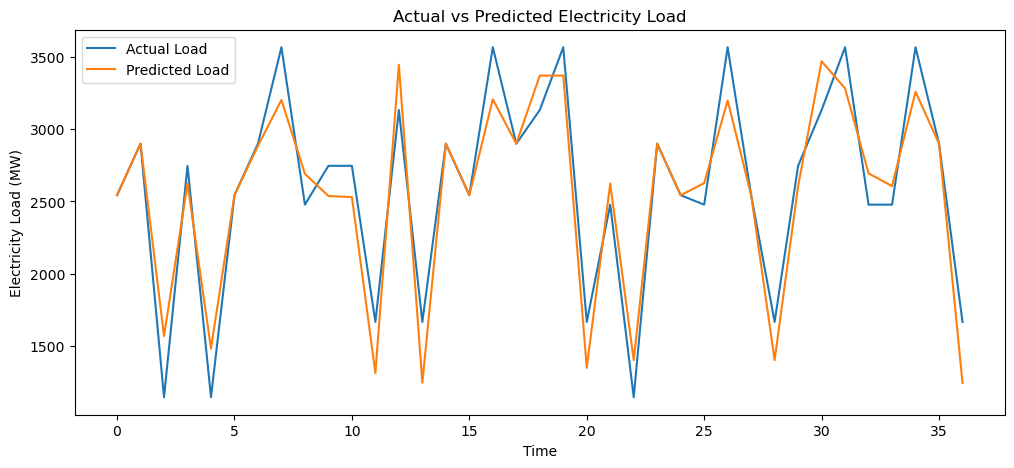

In [29]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12,5))

plt.plot(
    y_test.values[:100],
    label="Actual Load"
)

plt.plot(
    prediction[:100],
    label="Predicted Load"
)

plt.xlabel("Time")
plt.ylabel("Electricity Load (MW)")
plt.title("Actual vs Predicted Electricity Load")

plt.legend()

plt.show()

In [30]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": model.feature_importances_

})


importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
1,Month,0.420096
7,wind_speed,0.274797
5,temperature,0.224184
4,Weekday,0.051905
2,Day,0.011602
8,rain,0.009613
6,humidity,0.007804
0,Year,0.000000
3,Hour,0.000000


In [31]:
pip install joblib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [32]:
import joblib


joblib.dump(
    model,
    "electricity_load_model.pkl"
)

['electricity_load_model.pkl']

In [33]:
loaded_model = joblib.load(
    "electricity_load_model.pkl"
)


loaded_model.predict(
    X_test.head()
)

array([2543.        , 2900.        , 1567.67185714, 2623.20603227,
       1480.53307143])

In [34]:
def predict_load(
    year,
    month,
    day,
    hour,
    weekday,
    temperature,
    humidity,
    wind_speed,
    rain
):

    input_data = [[
        year,
        month,
        day,
        hour,
        weekday,
        temperature,
        humidity,
        wind_speed,
        rain
    ]]


    result = model.predict(input_data)[0]


    if result > 3000:
        return f"{result:.2f} MW - HIGH LOAD ALERT"

    else:
        return f"{result:.2f} MW - Normal"

In [35]:
predict_load(
2026,
1,
7,
18,
2,
32,
60,
5,
0
)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


'2550.89 MW - Normal'